# installations

In [0]:
import pandas as pd
from pyspark.sql.types import StructType, StructField, IntegerType, DoubleType, DateType

In [0]:
# Monthly net sales & bill count history per store — this already exists as a
# Gold table, no new feature table needed for this one.
history_df = spark.sql("""
SELECT
  store_id,
  bill_month_start,
  total_net_sales,
  total_bills
FROM gold_vw_sales_summary_monthly
ORDER BY store_id, bill_month_start
""")
display(history_df)

store_id,bill_month_start,total_net_sales,total_bills
14775,2024-01-01,87124.23362578452,493
14775,2024-02-01,82675.0203070119,454
14775,2024-03-01,76656.7700857725,428
14775,2024-04-01,68738.40000129119,392
14775,2024-05-01,73019.46008765325,417
14775,2024-06-01,80973.30020478182,463
14775,2024-07-01,98714.25996998884,563
14775,2024-08-01,91136.47996893339,471
14775,2024-09-01,64629.679928120226,399
14775,2024-10-01,97680.41114786081,489


In [0]:
# Schema of what each store's forecast returns
forecast_schema = StructType([
    StructField("store_id", IntegerType()),
    StructField("forecast_month", DateType()),
    StructField("predicted_net_sales", DoubleType()),
    StructField("lower_bound", DoubleType()),
    StructField("upper_bound", DoubleType()),
])
 
# COMMAND ----------
 
def forecast_store(pdf: pd.DataFrame) -> pd.DataFrame:
    """Fits one Prophet model per store (called once per store_id group)."""
    from prophet import Prophet
 
    store_id = int(pdf["store_id"].iloc[0])
 
    prophet_df = (
        pdf.rename(columns={"bill_month_start": "ds", "total_net_sales": "y"})[["ds", "y"]]
        .sort_values("ds")
    )
 
    # Skip stores without enough history to forecast reliably
    if len(prophet_df) < 6:
        return pd.DataFrame(columns=[
            "store_id", "forecast_month", "predicted_net_sales", "lower_bound", "upper_bound"
        ])
 
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(prophet_df)
 
    future = model.make_future_dataframe(periods=1, freq="MS")  # MS = month-start
    forecast = model.predict(future)
    next_month = forecast.iloc[[-1]]  # last row = the newly forecasted month
 
    return pd.DataFrame({
        "store_id":            [store_id],
        "forecast_month":      [next_month["ds"].values[0]],
        "predicted_net_sales": [round(float(next_month["yhat"].values[0]), 2)],
        "lower_bound":         [round(float(next_month["yhat_lower"].values[0]), 2)],
        "upper_bound":         [round(float(next_month["yhat_upper"].values[0]), 2)],
    })

In [0]:
%pip install prophet

# Run Prophet for every store in parallel
store_forecasts = (
    history_df
    .groupBy("store_id")
    .applyInPandas(forecast_store, schema=forecast_schema)
)
display(store_forecasts.orderBy("store_id"))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 18.2 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


store_id,forecast_month,predicted_net_sales,lower_bound,upper_bound
14775,2026-07-01,127902.14,118772.39,137330.42
14782,2026-07-01,601082.32,577418.56,624856.82
14783,2026-07-01,197179.84,188599.84,204460.06
15178,2026-07-01,766030.17,745128.24,785014.01
15475,2026-07-01,56058.69,50218.64,61892.38
15994,2026-07-01,174166.29,133893.48,213164.15
16028,2026-07-01,108173.09,96653.82,119679.07
16070,2026-07-01,184652.28,175700.93,192896.61
16257,2026-07-01,1291985.81,1155515.64,1435906.64
16868,2026-07-01,212414.92,185392.09,239742.68


In [0]:
# Compare forecast against the latest actual month, so it's obvious at a
# glance which stores are predicted to grow vs decline
comparison = spark.sql("""
WITH latest_actual AS (
  SELECT store_id, total_net_sales AS latest_month_net_sales
  FROM gold_vw_sales_summary_monthly a
  WHERE bill_month_start = (
    SELECT MAX(bill_month_start) FROM gold_vw_sales_summary_monthly b
    WHERE b.store_id = a.store_id
  )
)
SELECT
  f.store_id,
  f.forecast_month,
  la.latest_month_net_sales,
  f.predicted_net_sales,
  ROUND((f.predicted_net_sales - la.latest_month_net_sales) * 100.0
        / NULLIF(la.latest_month_net_sales, 0), 2) AS pct_change,
  f.lower_bound,
  f.upper_bound
FROM {store_forecasts} f
JOIN latest_actual la ON f.store_id = la.store_id
ORDER BY pct_change DESC
""", store_forecasts=store_forecasts)
display(comparison)

store_id,forecast_month,latest_month_net_sales,predicted_net_sales,pct_change,lower_bound,upper_bound
25874,2026-07-01,2093258.3762897253,9765310.36,366.51,9765310.35,9765310.36
18896,2026-07-01,120714.96012675762,486343.06,302.89,362689.67,602323.78
25870,2026-07-01,3027212.8520941734,6941926.21,129.32,6897693.15,6980568.67
25248,2026-07-01,1934670.7925558686,3583511.96,85.23,3580764.39,3586306.16
25243,2026-07-01,2621024.5468159914,4287688.44,63.59,4285233.6,4290241.96
25247,2026-07-01,1815756.845940113,2727576.21,50.22,2727518.4,2727628.59
17378,2026-07-01,14079.39999294281,20346.67,44.51,18824.26,21947.96
25246,2026-07-01,806757.1808280349,1057535.43,31.08,1055679.01,1059444.51
18494,2026-07-01,447548.69039976597,553590.2,23.69,521244.13,589533.21
17741,2026-07-01,1065703.712247014,1317818.24,23.66,1293054.48,1340709.71


In [0]:
# Save as a queryable forecast table, refreshable alongside Silver/Gold
comparison.write.mode("overwrite").saveAsTable("pharmacy_sales.gold.forecast_store_next_month")

In [0]:
import matplotlib.pyplot as plt
 
comparison_pd = comparison.toPandas().sort_values("pct_change", ascending=False)
history_pd = history_df.toPandas()

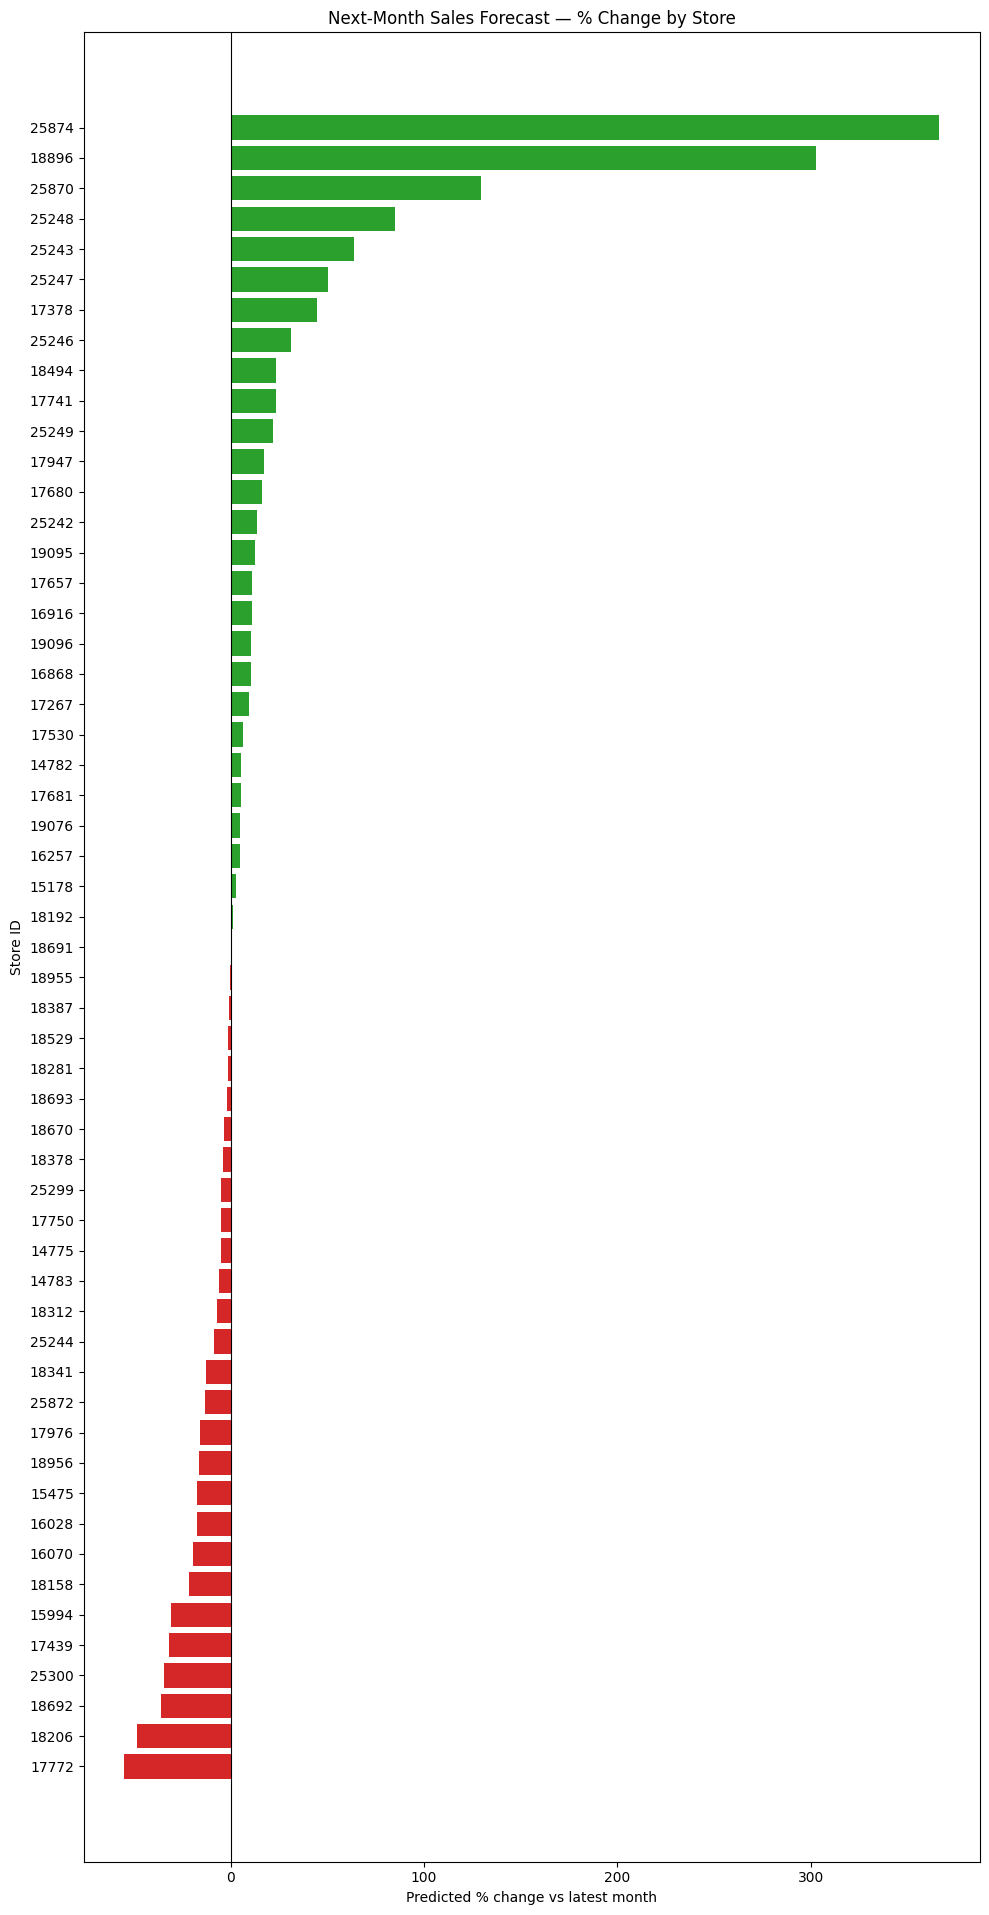

In [0]:
# Horizontal bar chart of predicted % change per store for the next month.
# Green bars indicate forecast growth, red bars indicate forecast decline
# versus the latest actual month. Sorted by pct_change descending so the
# biggest predicted winners appear at the top.
colors = ["#2ca02c" if x >= 0 else "#d62728" for x in comparison_pd["pct_change"]]
 
plt.figure(figsize=(10, max(4, len(comparison_pd) * 0.35)))
plt.barh(comparison_pd["store_id"].astype(str), comparison_pd["pct_change"], color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Predicted % change vs latest month")
plt.ylabel("Store ID")
plt.title("Next-Month Sales Forecast — % Change by Store")
plt.gca().invert_yaxis()  # highest % change at the top
plt.tight_layout()
plt.show()

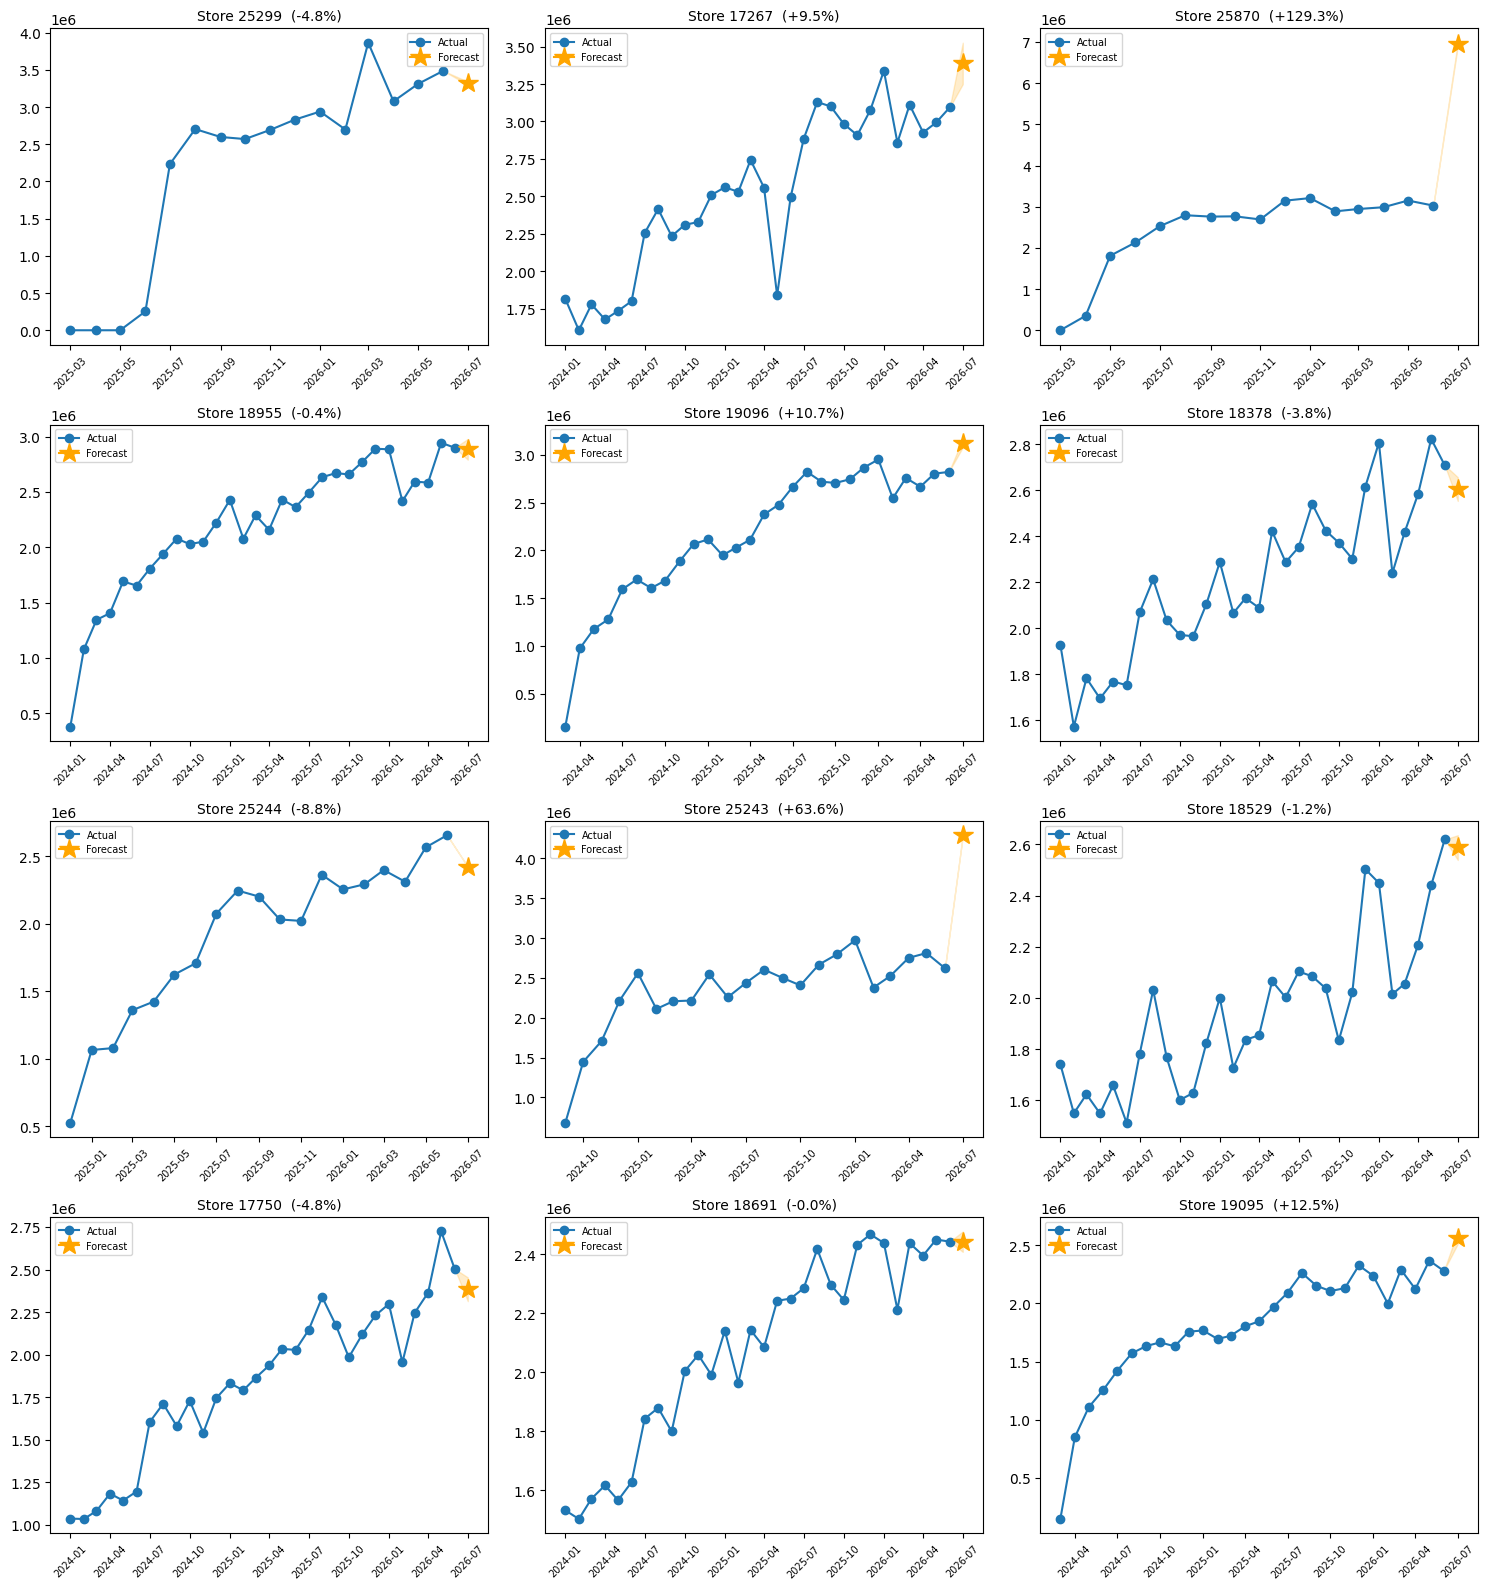

In [0]:
MAX_STORES_TO_PLOT = 12
 
top_stores = (
    comparison_pd
    .reindex(comparison_pd["latest_month_net_sales"].sort_values(ascending=False).index)
    ["store_id"]
    .head(MAX_STORES_TO_PLOT)
    .tolist()
)
 
n_cols = 3
n_rows = -(-len(top_stores) // n_cols)  # ceil division
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows), squeeze=False)
 
for idx, store_id in enumerate(top_stores):
    ax = axes[idx // n_cols][idx % n_cols]
 
    hist = history_pd[history_pd["store_id"] == store_id].sort_values("bill_month_start")
    fc = comparison_pd[comparison_pd["store_id"] == store_id].iloc[0]
 
    ax.plot(hist["bill_month_start"], hist["total_net_sales"], marker="o", label="Actual")
    ax.plot(fc["forecast_month"], fc["predicted_net_sales"], marker="*", markersize=15,
            color="orange", label="Forecast")
    ax.fill_between(
        [hist["bill_month_start"].iloc[-1], fc["forecast_month"]],
        [hist["total_net_sales"].iloc[-1], fc["lower_bound"]],
        [hist["total_net_sales"].iloc[-1], fc["upper_bound"]],
        color="orange", alpha=0.2
    )
    ax.set_title(f"Store {store_id}  ({fc['pct_change']:+.1f}%)", fontsize=10)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.legend(fontsize=7)
 
# Hide any unused subplot slots when store count doesn't fill the grid evenly
for idx in range(len(top_stores), n_rows * n_cols):
    axes[idx // n_cols][idx % n_cols].axis("off")
 
plt.tight_layout()
plt.show()